In [31]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import copy
from scipy.spatial.distance import cdist
import seaborn as sns

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [33]:
_BATCH_SIZE  = 64 
_NUM_WORKERS = 0  

In [34]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        # transforms.Normalize(mean= (0.1307,), std= (0.3081,))
    ]
)

In [35]:
trainset = torchvision.datasets.MNIST(
    root= './data', 
    train= True, 
    transform= transform,
    download= True
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size= _BATCH_SIZE,
    shuffle= True,
    num_workers= _NUM_WORKERS
)

testset = torchvision.datasets.MNIST(
    root= './data', 
    train= False, 
    transform= transform,
    download= True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size= _BATCH_SIZE,
    shuffle= False,
    num_workers= _NUM_WORKERS
)

In [36]:
print(f"Number of training images: {len(trainset)}")
print(f"Number of test images: {len(testset)}")
print(f"Classes: {trainloader.dataset.classes} : {len(trainloader.dataset.classes)} classes")

Number of training images: 60000
Number of test images: 10000
Classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine'] : 10 classes


In [37]:
imgs, lbs = next(iter(trainloader))

In [38]:
def img_show(img):
    img = img.numpy()
    plt.imshow(np.transpose(img, (1, 2, 0)), cmap='gray')
    plt.axis('off')
    plt.show()

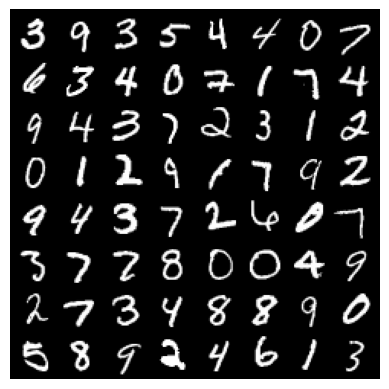

In [39]:
img_show(torchvision.utils.make_grid(imgs))

In [40]:
print(f"Pixel-values range: \n\tmin = {imgs.min().item():.2f} \n\tmax = {imgs.max().item():.2f}")

Pixel-values range: 
	min = 0.00 
	max = 1.00


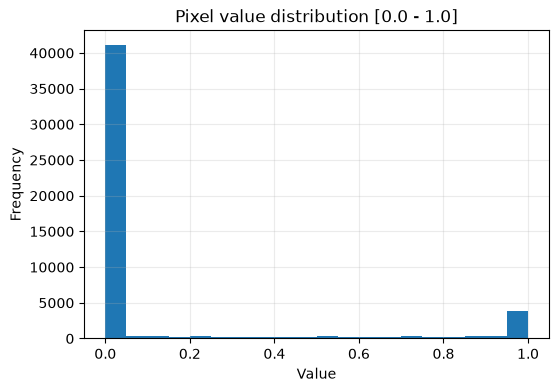

In [41]:
pxs = imgs.numpy().flatten()

plt.figure(figsize=(6, 4))
plt.hist(pxs, bins= 20)
plt.title('Pixel value distribution [0.0 - 1.0]')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha= 0.25)
plt.show()

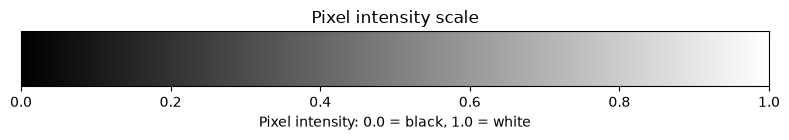

In [42]:
gradient = np.linspace(0, 1, 256).reshape(1, -1)

plt.figure(figsize=(8, 1.5))
plt.gca().get_yaxis().set_visible(False)

plt.imshow(gradient, cmap='gray', aspect='auto', extent=[0, 1, 0, 1])

plt.xlabel('Pixel intensity: 0.0 = black, 1.0 = white')
plt.title('Pixel intensity scale')

plt.tight_layout()
plt.show()

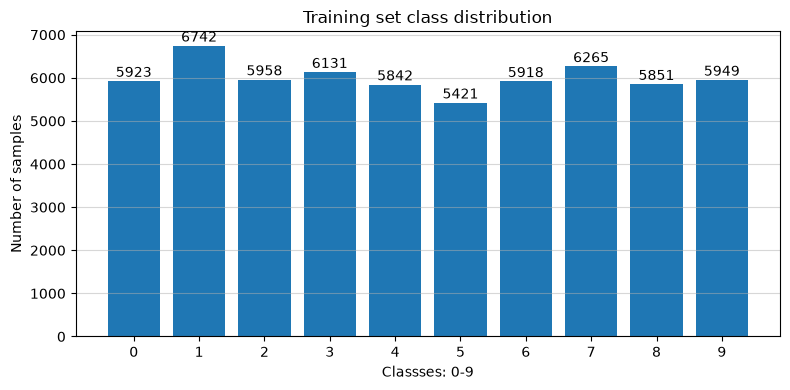

In [43]:
cls  = np.arange(10)
cnts = torch.bincount(trainset.targets).numpy() 

plt.figure(figsize= (8, 4))

bars = plt.bar(cls, cnts)

plt.xlabel('Classses: 0-9')
plt.ylabel('Number of samples')
plt.title('Training set class distribution')
plt.xticks(cls) 

plt.grid(axis='y', alpha= 0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, int(yval), ha= 'center')

plt.tight_layout()
plt.show()

In [44]:
print(f"Tensor shape: {imgs.shape}")

class CNN():
    pass

Tensor shape: torch.Size([64, 1, 28, 28])


In [45]:
class MNISTCNN(nn.Module):
    def __init__(self):
        super(MNISTCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def extract_features(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(-1, 32 * 7 * 7)
        return F.relu(self.fc1(x))

    def forward(self, x):
        x = self.extract_features(x)
        return self.fc2(x)

In [46]:
def train_model(dataloader, model_name, epochs=2):
    print(f"\nTraining {model_name}...")
    model = MNISTCNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for imgs, lbs in dataloader:
            imgs, lbs = imgs.to(device), lbs.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), lbs)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"  Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(dataloader):.4f}")
    return model

clean_model = train_model(trainloader, "Clean Baseline", epochs=2)


Training Clean Baseline...
  Epoch 1/2 | Loss: 0.2351
  Epoch 2/2 | Loss: 0.0650


In [47]:
clean_model.eval()
class_features = {i: [] for i in range(10)}
with torch.no_grad():
    for imgs, lbs in trainloader:
        imgs = imgs.to(device)
        feats = clean_model.extract_features(imgs)
        for i in range(len(lbs)):
            class_features[lbs[i].item()].append(feats[i].cpu().numpy())
        if len(class_features[0]) > 200:
            break

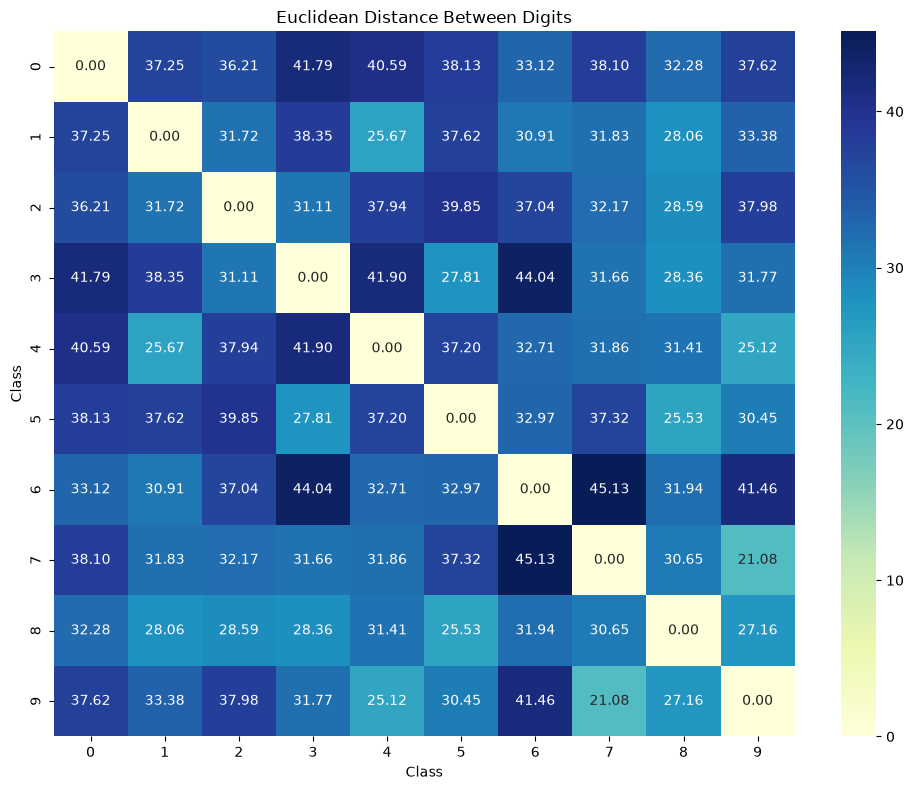

In [48]:
centroids = np.zeros((10, 128))
for i in range(10):
    centroids[i] = np.mean(class_features[i], axis=0)

dist_matrix = cdist(centroids, centroids, metric='euclidean')

plt.figure(figsize=(10, 8))
sns.heatmap(dist_matrix, annot=True, fmt=".2f", cmap="YlGnBu", 
            xticklabels=range(10), yticklabels=range(10))

plt.title("Euclidean Distance Between Digits")
plt.xlabel("Class")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

In [49]:
def create_label_flipping_baseline(train_set, source_class, target_class, poison_ratio=0.12):
    poisoned_set = copy.deepcopy(train_set)
    if isinstance(poisoned_set.targets, torch.Tensor):
        targets = poisoned_set.targets.clone().detach()
    else:
        targets = torch.tensor(poisoned_set.targets).clone().detach()
        
    source_indices = (targets == source_class).nonzero(as_tuple=True)[0]
    global_budget = int(len(train_set) * poison_ratio)
    num_to_poison = min(global_budget, len(source_indices))
    
    perm = torch.randperm(len(source_indices))
    poison_indices = source_indices[perm[:num_to_poison]]
    targets[poison_indices] = target_class
    poisoned_set.targets = targets
    
    return poisoned_set

In [50]:
flipped_trainset = create_label_flipping_baseline(
    trainset, 
    source_class=3, 
    target_class=8, 
    poison_ratio=0.12
)

labelflip_loader = torch.utils.data.DataLoader(
    flipped_trainset, 
    batch_size=_BATCH_SIZE, 
    shuffle=True
)

In [51]:
def create_backdoor_baseline(train_set, target_class, poison_ratio=0.10):
    poisoned_set = copy.deepcopy(train_set)
    num_samples = len(poisoned_set.data)
    num_to_poison = int(num_samples * poison_ratio)
    poison_indices = torch.randperm(num_samples)[:num_to_poison]
    
    for idx in poison_indices:
        img = poisoned_set.data[idx]
        img[24:27, 24:27] = 255 
        poisoned_set.data[idx] = img
        poisoned_set.targets[idx] = target_class
        
    return poisoned_set

In [52]:
backdoor_trainset = create_backdoor_baseline(
    trainset, 
    target_class=8,
    poison_ratio=0.10
)

backdoor_loader = torch.utils.data.DataLoader(
    backdoor_trainset, 
    batch_size=_BATCH_SIZE, 
    shuffle=True
)

In [53]:
def evaluate_attack(model, testloader, attack_type="clean", source_class=3, target_class=8):
    model.eval()
    correct_clean, total_clean, asr_success, asr_total = 0, 0, 0, 0
    with torch.no_grad():
        for imgs, lbs in testloader:
            imgs, lbs = imgs.to(device), lbs.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            total_clean += lbs.size(0)
            correct_clean += (preds == lbs).sum().item()
            
            if attack_type in ["clean", "label_flip"]:
                mask = (lbs == source_class)
                if mask.sum() > 0:
                    asr_total += mask.sum().item()
                    asr_success += (preds[mask] == target_class).sum().item()
            elif attack_type == "backdoor":
                mask = (lbs != target_class)
                if mask.sum() > 0:
                    trig_imgs = imgs[mask].clone()
                    trig_imgs[:, :, 24:27, 24:27] = 1.0 
                    _, trig_preds = torch.max(model(trig_imgs), 1)
                    asr_total += trig_imgs.size(0)
                    asr_success += (trig_preds == target_class).sum().item()
                    
    return 100.0 * correct_clean / total_clean, 100.0 * asr_success / asr_total if asr_total > 0 else 0.0

In [54]:
final_accuracies, final_asrs = [], []
labels = ['Clean', 'Label-Flipping\n(3->8, 12%)', 'Backdoor\n(Trigger, 10%)', 'Proposed Similarity\n(7->9, 8%)']

In [55]:
clean_model = train_model(trainloader, "Clean Baseline")
acc, asr = evaluate_attack(clean_model, testloader, attack_type="clean")
final_accuracies.append(acc); final_asrs.append(asr)


Training Clean Baseline...
  Epoch 1/2 | Loss: 0.2112
  Epoch 2/2 | Loss: 0.0559


In [56]:
flip_model = train_model(labelflip_loader, "Label-Flip Baseline")
acc, asr = evaluate_attack(flip_model, testloader, attack_type="label_flip", source_class=3, target_class=8)
final_accuracies.append(acc); final_asrs.append(asr)


Training Label-Flip Baseline...
  Epoch 1/2 | Loss: 0.2477
  Epoch 2/2 | Loss: 0.0647


In [57]:
backdoor_model = train_model(backdoor_loader, "Backdoor Baseline")
acc, asr = evaluate_attack(backdoor_model, testloader, attack_type="backdoor", target_class=8)
final_accuracies.append(acc); final_asrs.append(asr)


Training Backdoor Baseline...
  Epoch 1/2 | Loss: 0.2241
  Epoch 2/2 | Loss: 0.0625


In [58]:
sim_trainset = create_label_flipping_baseline(
    trainset, 
    source_class=7, 
    target_class=9, 
    poison_ratio=0.08
)

sim_loader = torch.utils.data.DataLoader(
    sim_trainset, 
    batch_size=_BATCH_SIZE, 
    shuffle=True
)

In [59]:
sim_model = train_model(sim_loader, "Similarity Attack")
acc, asr = evaluate_attack(sim_model, testloader, attack_type="label_flip", source_class=7, target_class=9)
final_accuracies.append(acc); final_asrs.append(asr)


Training Similarity Attack...
  Epoch 1/2 | Loss: 0.2676
  Epoch 2/2 | Loss: 0.1187


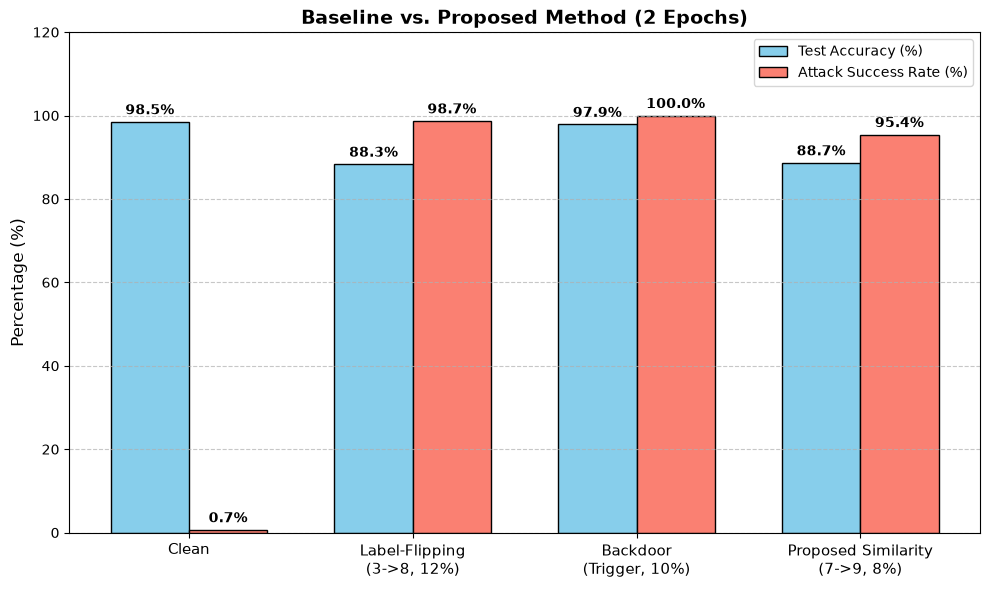

In [60]:
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, final_accuracies, width, label='Test Accuracy (%)', color='skyblue', edgecolor='black')
rects2 = ax.bar(x + width/2, final_asrs, width, label='Attack Success Rate (%)', color='salmon', edgecolor='black')

ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Baseline vs. Proposed Method (2 Epochs)', fontsize=14, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 120); ax.legend(loc='upper right')

for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.1f}%', xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()